In [296]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
import csv
from decimal import Decimal
from IPython.display import display, Math
import math

In [297]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [298]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [299]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_model : array_like
        Model predictions.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    n_params : int
        Number of fitted parameters.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs)
    y_model = np.asarray(y_model)
    y_err_low = np.asarray(y_err_low)
    y_err_high = np.asarray(y_err_high)

    # Use the appropriate uncertainty depending on which side of the data
    sigma = np.where(y_model > y_obs, y_err_high, y_err_low)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [300]:
def calculate_nmad(y, err_high, err_low, y_model):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    sigma = np.where(
        residuals > 0,
        err_low,   # data lie above model
        err_high   # data lie below model
    )

    normalised_residuals = residuals / sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [301]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [302]:
def format_value_uncertainty(value, uncertainty):
    """
    Format a value ± uncertainty using standard significant-figure rules.
    """
    if uncertainty == 0:
        return f"{value:.3f}", "0"

    # 1 significant figure (2 if first digit is 1 or 2)
    exponent = math.floor(math.log10(abs(uncertainty)))
    first_digit = int(abs(uncertainty) / 10**exponent)

    sig_figs = 2 if first_digit in [1, 2] else 1

    decimals = -(exponent - (sig_figs - 1))

    value_rounded = round(value, decimals)
    uncertainty_rounded = round(uncertainty, decimals)

    fmt = f"{{:.{max(decimals,0)}f}}"

    return fmt.format(value_rounded), fmt.format(uncertainty_rounded)

In [303]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl

In [304]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [305]:
def filter_best_DIC(stellar_table, stellar_AGN_table):
    """
    Select the stellar mass from either the stellar-only or stellar+AGN fit
    depending on the DIC comparison.

    Uses the AGN model if:
        DIC_AGN < DIC_stellar - 6

    Returns a table containing the best stellar mass estimates and the model
    selected for each galaxy.
    """

    # Match galaxies by ID
    # Some of the headers are the same across both tables, so to avoid confusion, 
    # uniq_col_name keeps the col_name and appends it with stellar or AGN depending on which table it came from.
    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # Read the relevant columns
    DIC_stellar = np.asarray(table["DIC_stellar"], dtype=float)
    DIC_AGN = np.asarray(table["DIC_AGN"], dtype=float)

    mass_stellar_Q16 = np.asarray(table["StellarMassQ16_stellar"], dtype=float)
    mass_stellar_Q50 = np.asarray(table["StellarMassQ50_stellar"], dtype=float)
    mass_stellar_Q84 = np.asarray(table["StellarMassQ84_stellar"], dtype=float)

    mass_AGN_Q16 = np.asarray(table["StellarMassQ16_AGN"], dtype=float)
    mass_AGN_Q50 = np.asarray(table["StellarMassQ50_AGN"], dtype=float)
    mass_AGN_Q84 = np.asarray(table["StellarMassQ84_AGN"], dtype=float)

    # Decide which model to use
    use_AGN = np.zeros(len(table), dtype=bool)

    mask = ~np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)
    use_AGN[mask] = DIC_AGN[mask] < (DIC_stellar[mask] - 6)

    # If only AGN exists, use it
    use_AGN[np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)] = True

    # Select best masses
    best_mass_Q16 = np.where(use_AGN, mass_AGN_Q16, mass_stellar_Q16)
    best_mass_Q50 = np.where(use_AGN, mass_AGN_Q50, mass_stellar_Q50)
    best_mass_Q84 = np.where(use_AGN, mass_AGN_Q84, mass_stellar_Q84)
    best_model = np.where(use_AGN, "stellar_AGN", "stellar")

    table["Best_StellarMassQ16"] = best_mass_Q16
    table["Best_StellarMassQ50"] = best_mass_Q50
    table["Best_StellarMassQ84"] = best_mass_Q84
    table["Best_Model"] = best_model

    print("DIC filtered table names: ",table.colnames)
    
    return table

In [306]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_uncertainty : float
        1-sigma uncertainty on slope.
    intercept_uncertainty : float
        1-sigma uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    if line_kwargs is None:
        line_kwargs = {"color": colour, "lw": 2, "linestyle": "--"}

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    x_plot = np.linspace(np.min(x)*0.99, np.max(x)*1.01, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_uncertainty) * x_plot
               + (intercept + intercept_uncertainty))

    y_lower = ((gradient - gradient_uncertainty) * x_plot
               + (intercept - intercept_uncertainty))

    ax.plot(x_plot, y, color=colour, label=label,zorder=zorder)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, **band_kwargs)
    

In [307]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    plot_points,
):
    
    popt, pcov = curve_fit(straight_line, x, y, p0=None)

    gradient = popt[0]
    intercept = popt[1]

    gradient_uncertainty = np.sqrt(np.diag(pcov))[0]
    intercept_uncertainty = np.sqrt(np.diag(pcov))[1]

    x_dummy_data = np.linspace(np.min(x),np.max(x),500)

    weighted_red_chi = weighted_reduced_chi_squared(y, y_lower_err, y_upper_err, straight_line(x, gradient, intercept),2)

    scatter = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept))

    if ax is not None:
        
        if plot_points==True:

            ax.errorbar(
                x,
                y,
                xerr=[x_lower_err, x_upper_err],
                yerr=[y_lower_err, y_upper_err],
                fmt='none',
                alpha=0.15,
                lw=0.8,
                zorder=2
            )

            ax.scatter(
                x,
                y,
                s=20,
                color=plot_colours,
                zorder=3
            )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Scatter (NMAD of normalised residuals) = {scatter:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi


In [308]:
def plot_stellar_masses(combined_table):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    # Stellar mass data:
    stellar_only_q16 = combined_table["StellarMassQ16_stellar"].data
    stellar_only_q50 = combined_table["StellarMassQ50_stellar"].data
    stellar_only_q84 = combined_table["StellarMassQ84_stellar"].data
    
    stellar_AGN_q16 = combined_table["StellarMassQ16_AGN"].data
    stellar_AGN_q50 = combined_table["StellarMassQ50_AGN"].data
    stellar_AGN_q84 = combined_table["StellarMassQ84_AGN"].data


    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_q50)
    ]
    xerr = [
        np.log10(stellar_AGN_q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_q50)
    ]
    
    fig, ax = plt.subplots(figsize=(10,10))

    (ax, stellar_dummy_data, gradient, gradient_uncertainty, intercept, intercept_uncertainty, weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=np.log10(stellar_AGN_q50),
        x_upper_err=xerr[1],
        x_lower_err=xerr[0],
        y=np.log10(stellar_only_q50),
        y_upper_err=yerr[1],
        y_lower_err=yerr[0],
        plot_colours='C0',
        ax=ax,
        plot_points=True,
    )
    
    plot_best_fit_with_uncertainty(ax, stellar_dummy_data, gradient, intercept,
                              gradient_uncertainty,
                              intercept_uncertainty,
                              label='Line of best fit',
                              colour='red',
                              fill=False,
                              zorder=1,
                              )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_q50)),np.min(np.log10(stellar_only_q50)))
    mmax = max(np.max(np.log10(stellar_AGN_q50)),np.max(np.log10(stellar_only_q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)',fontdict={'fontsize': 15})
    ax.set_ylim(0.95 * mmin, 1.05 * mmax)
    ax.set_xlim(0.95 * mmin, 1.05 * mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [309]:
def bhm_vs_sm_plot(stellar_table, stellar_AGN_table):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)
    #------------------------------------------------------------------------------------------------------------------------------------------

    jades = np.asarray(["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"], dtype=str)
    primer =  np.asarray(["PRIMER-COSMOS","PRIMER-UDS"], dtype=str)
    ceers = np.asarray(["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"], dtype=str)

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='JADES',
                markerfacecolor='tab:blue',
                markeredgecolor='k',
                markersize=7),
                
            Line2D([0], [0], marker='o', color='w',
                label='CEERS',
                markerfacecolor='tab:purple',
                markeredgecolor='k',
                markersize=7),
                    
            Line2D([0], [0], marker='o', color='w',
                label='PRIMER',
                markerfacecolor='tab:gray',
                markeredgecolor='k',
                markersize=7)    ]
    
    def colours(survey):
        colours = np.empty(len(survey), dtype=object)
        for i, s in enumerate(survey):
            if s in jades:
                colours[i] = 'tab:blue'
            if s in ceers:
                colours[i] = 'tab:purple'
            if s in primer:
                colours[i] = 'tab:gray'
        return colours

    #------------------------------------------------------------------------------------------------------------------------------------------
    # Stellar+AGN
    survey_AGN = stellar_AGN_table["SURVEY"].data

    colours_AGN = colours(survey_AGN)

    stellar_mass_Q16_AGN = stellar_AGN_table["StellarMassQ16"].data
    stellar_mass_Q50_AGN = stellar_AGN_table["StellarMassQ50"].data
    stellar_mass_Q84_AGN = stellar_AGN_table["StellarMassQ84"].data
    
    bh_mass_AGN = stellar_AGN_table["BH_MASS"].data
    bh_mass_lower_err_AGN = stellar_AGN_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_AGN = stellar_AGN_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_AGN = np.log10(bh_mass_AGN)
    log_bh_mass_lower_err_AGN = log_bh_mass_AGN - np.log10(np.abs(bh_mass_AGN - bh_mass_lower_err_AGN))
    log_bh_mass_upper_err_AGN = np.log10(bh_mass_AGN + bh_mass_upper_err_AGN) - log_bh_mass_AGN
    
    log_stellar_mass_AGN = np.log10(stellar_mass_Q50_AGN)
    log_stellar_mass_upper_err_AGN = np.log10(stellar_mass_Q84_AGN) - log_stellar_mass_AGN
    log_stellar_mass_lower_err_AGN = log_stellar_mass_AGN - np.log10(stellar_mass_Q16_AGN)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # stellar only
    survey_stellar = stellar_table["SURVEY"].data

    colours_stellar = colours(survey_stellar)

    stellar_mass_Q16_stellar = stellar_table["StellarMassQ16"].data
    stellar_mass_Q50_stellar = stellar_table["StellarMassQ50"].data
    stellar_mass_Q84_stellar = stellar_table["StellarMassQ84"].data
    
    bh_mass_stellar = stellar_table["BH_MASS"].data
    bh_mass_lower_err_stellar = stellar_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_stellar = stellar_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_stellar = np.log10(bh_mass_stellar)
    log_bh_mass_lower_err_stellar = log_bh_mass_stellar - np.log10(np.abs(bh_mass_stellar - bh_mass_lower_err_stellar))
    log_bh_mass_upper_err_stellar = np.log10(bh_mass_stellar + bh_mass_upper_err_stellar) - log_bh_mass_stellar
    
    log_stellar_mass_stellar = np.log10(stellar_mass_Q50_stellar)
    log_stellar_mass_upper_err_stellar = np.log10(stellar_mass_Q84_stellar) - log_stellar_mass_stellar
    log_stellar_mass_lower_err_stellar = log_stellar_mass_stellar - np.log10(stellar_mass_Q16_stellar)
    #------------------------------------------------------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10,10))

    # Calculate the line of best fit for stellar only data:
    (_, stellar_x_dummy_data, stellar_gradient, stellar_gradient_uncertainty, stellar_intercept, stellar_intercept_uncertainty, stellar_weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=log_stellar_mass_stellar,
        x_upper_err=log_stellar_mass_upper_err_stellar,
        x_lower_err=log_stellar_mass_lower_err_stellar,
        y=log_bh_mass_stellar,
        y_upper_err=log_bh_mass_upper_err_stellar,
        y_lower_err=log_bh_mass_lower_err_stellar,
        plot_colours=colours_stellar,
        ax=None,
        plot_points=False,
    )
    
    
    # Calculate the best fit for stellar+AGN data:
    (ax, AGN_x_dummy_data, AGN_gradient, AGN_gradient_uncertainty, AGN_intercept, AGN_intercept_uncertainty, AGN_weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=log_stellar_mass_AGN,
            x_upper_err=log_stellar_mass_upper_err_AGN,
            x_lower_err=log_stellar_mass_lower_err_AGN,
            y=log_bh_mass_AGN,
            y_upper_err=log_bh_mass_upper_err_AGN,
            y_lower_err=log_bh_mass_lower_err_AGN,
            plot_colours=colours_AGN,
            ax=ax,
            plot_points=True,
        )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        AGN_gradient,
        AGN_intercept,
        AGN_gradient_uncertainty,
        AGN_intercept_uncertainty,
        "Stellar+AGN fit",
        "red",
        fill=True,
        zorder=3,
    )
    
    # Plot equation of stellar best fit but using AGN stellar masses
    
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        stellar_gradient,
        stellar_intercept,
        stellar_gradient_uncertainty,
        stellar_intercept_uncertainty,
        "Stellar fit",
        "blue",
        fill=False,
        zorder=2
    )
    
    # Plot RV line of best fit on AGN stellar masses
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        RV_gradient,
        RV_intercept,
        RV_gradient_uncertainty,
        RV_intercept_uncertainty,
        "Reines & Volonteri",
        "black",
        fill=True,
        zorder=1,
    )

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    
    line_legend = ax.legend(loc='upper right')
    ax.legend(handles=legend_elements, title="Survey", loc='upper left')
    ax.add_artist(line_legend)
    plt.show()


    grad_AGN, grad_err_AGN = format_value_uncertainty(AGN_gradient, AGN_gradient_uncertainty)
    inter_AGN, inter_err_AGN = format_value_uncertainty(AGN_intercept, AGN_intercept_uncertainty)

    print("Line of best fit equation for AGN fit: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad_AGN} \pm {grad_err_AGN})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter_AGN} \pm {inter_err_AGN})$"
    ))
    

    RV_grad, RV_grad_err = format_value_uncertainty(RV_gradient, RV_gradient_uncertainty)
    RV_inter, RV_inter_err = format_value_uncertainty(RV_intercept, RV_intercept_uncertainty)
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_grad} \pm {RV_grad_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_inter} \pm {RV_inter_err})$"
    ))

    print("AGN_gradient =", AGN_gradient)
    print("AGN_intercept =", AGN_intercept)

    print("stellar_gradient =", stellar_gradient)
    print("stellar_intercept =", stellar_intercept)



Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    168   144R x 80C   [D, E, E, E, E, E, E, E, E, 5A, D, D, D, E, E, E, E, E, E, E, E, D, 55A, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, D, D, D, D, D, D, 18A, K, 21A, J, E, E, E, E, E, E, E, E, D, D, D, D, D, D, D]   



For plot below: 
Reduced chi squared = 129
Scatter (NMAD of normalised residuals) = 8.855


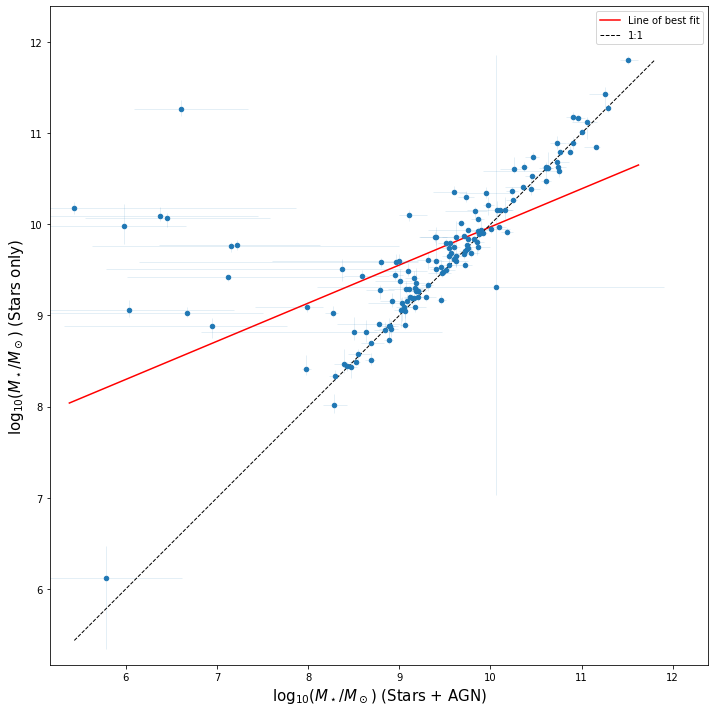


For plot below: 
Reduced chi squared = 7.96e+04
Scatter (NMAD of normalised residuals) = 8.855


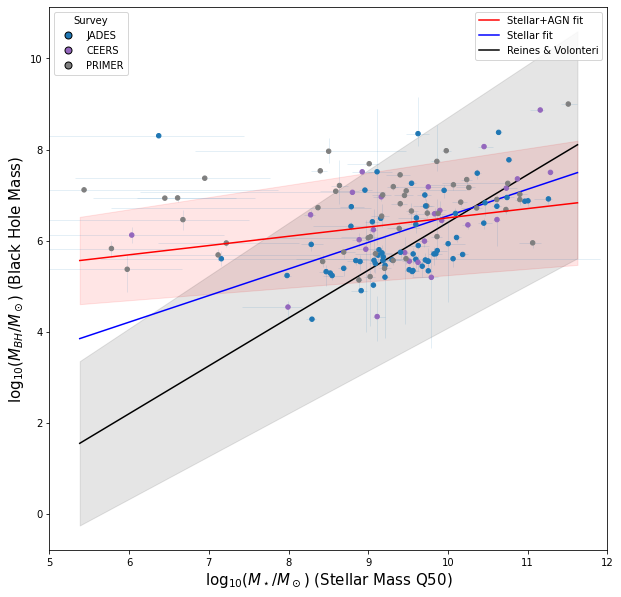

Line of best fit equation for AGN fit: 


<IPython.core.display.Math object>


Reines & Volonteri equation: 


<IPython.core.display.Math object>

AGN_gradient = 0.20300764166907237
AGN_intercept = 4.471066277425235
stellar_gradient = 0.5837967519158501
stellar_intercept = 0.7076356693092898


In [310]:
if __name__ == "__main__":
    
    stellar_only_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    stellar_AGN_Lbol_prior_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_lbol_prior_astro_cat.csv")
    # Contains posterior data from stellar only fit as well as fitted photometry (anything with AGN in the colname has zeros for consistency)

    # stellar_AGN_photom = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_fit_photom.csv")
    
    galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits")
    galaxy_table.rename_column("SURVEY_ID", "ID")
    #-----------------------------------------------------------------------------------------------------------------------
    
    combined_SED_tables = join(
        stellar_only_table,
        stellar_AGN_Lbol_prior_table,
        keys="ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )
    
    stellar_only_and_galaxy_table = join(
        stellar_only_table,
        galaxy_table,
        keys="ID"
    )

    stellar_AGN_and_galaxy_table = join(
        stellar_AGN_Lbol_prior_table,
        galaxy_table,
        keys="ID"
    )
    
    plot_stellar_masses(combined_SED_tables)

    bhm_vs_sm_plot(stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table)